

____________________
# Exploring MEI with Beautiful Soup:  Metadata and Music Data


### Authors

- Richard Freedman (Haverford College)
- Daniel Russo-Batterham (Melbourne University)
- Oleh Shostak (Haverford College)

### Last Updated August 2025

In this assignment, you will get an opportunity to engage, explore, and experiment with **XML** files through Python and **Beautiful Soup**. As you know, **XML** stands for **eXtensible Markup Language** and mainly serves to transport and store data. At its core, XML was designed to be **both machine- and human-readable**. In the case of music files, the common encoding standard is **MEI**, which stands for **Music Encoding Initiative** and is built on top of the XML framework.


Mainly, this assignment focuses on:

* **access**: downloading, storing, reading, processing XML files
* **checking and updating metadata**  enriching files that you bring to MEI from various sources (such as produced with MuseScore, MEI Friend, or Sibelius MEI Export Plugin)
* **analysis**: performing basic quantitative and qualitative analysis of XML files
* **interpretation**: exploring the meaning and utility of XML files from both analytical and creative perspectives 

As we deal with these files, we will make use of Beautiful Soup – a Python library that makes interacting with XML and HTML friendly and comfortable. Or at least tries to... You can access Beautiful Soup's documentation [here](https://www.crummy.com/software/BeautifulSoup/bs4/doc/).

Read the [Music 255 Beautiful Soup and MEI Tutorial for ideas on different ways to work with your files](https://github.com/RichardFreedman/Encoding_Music/blob/main/01_Tutorials/12_Beautiful_Soup_MEI.md).

XML files are guided by **markup rules**, which you can read more about [here](https://www.w3schools.com/xml/xml_syntax.asp) and consist of **elements**, which you can dive into [here](https://www.w3schools.com/xml/xml_elements.asp).

MEI files are primarily XML files with music-specific sections, elements, and structure. You can learn more about MEI [here](https://music-encoding.org/).


----

## 0. Import Libraries

In [81]:
import pandas as pd
import os
import bs4
from bs4 import BeautifulSoup
from lxml import etree # lxml is imported for xpath examples
import uuid

from pathlib import Path
import requests
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import math
import numpy as np

# Visualisation dependencies
import matplotlib.pyplot as plt
import textwrap
import networkx as nx
from pyvis.network import Network
import seaborn as sns

# from IPython.display import IFrame, display
from IPython.display import HTML, display



import warnings
warnings.filterwarnings('ignore')

import uuid
import glob

from datetime import datetime
import chardet
import random

import subprocess

### 1. Various Ways to Import MEI Files

In [100]:

# local files
file_list = sorted(glob.glob('MEI/*'))

# just the first file in that lis
file_list[2]


'MEI/Bach_BWV_0774.mei'

### Load your File(s) with Soup

The following function takes in a path to XML file, then returns 

- **soup** (that is, the **Beautiful Soup** version of the XML, so we can work with it)
- **original filename** (the original name of the file, which is needed for creating the new name)
- **revised filename** (the updated filename)


In [101]:
# here is the function that will return our tuple
def open_file(filename):
    with open(filename, 'rb') as file:
        # Detect the encoding
        result = chardet.detect(file.read())
        # Seek to the beginning of the file
        file.seek(0)
        # Decode the file using the detected encoding
        content = file.read().decode(result['encoding'])
        file_name = os.path.basename(filename)
        base_name, extension = os.path.splitext(file_name) 
        file_name_for_dict_check = base_name + extension
        revised_name = base_name + "_rev" + extension
        soup = BeautifulSoup(content, 'xml')
        
        return soup, file_name_for_dict_check, revised_name

In [104]:
my_file = file_list[2]
my_soup_with_names = open_file(my_file)

# here are the tree items from our tuple

# soup file itself
soup = my_soup_with_names[0]

# the full filename with extension
filename = my_soup_with_names[1]

# the full filename with extension, now with 'rev' as part of the basename
revised_name = my_soup_with_names[2]


Here you can scroll through the entire MEI file. Note the the `soup` object has a `prettify` method that makes the XML easier to read by indenting nested elements:

```python
print(soup.prettify())
```
```xml
<?xml version="1.0" encoding="utf-8"?>
<?xml-model href="https://music-encoding.org/schema/5.0/mei-all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?>
<?xml-model href="https://music-encoding.org/schema/5.0/mei-all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?>
<mei meiversion="5.0" xmlns="http://www.music-encoding.org/ns/mei">
 <meiHead xml:id="m6tn8nh">
  <fileDesc>
   <titleStmt>
    <title>
     Invention No. 1 in C major,  BWV 772
    </title>
    <respStmt>
     <persName auth="VIAF" auth.uri="https://viaf.org/viaf/12304462/" role="composer">
      Bach, Johann Sebastian
     </persName>
     <persName role="xml_editor">
      SchÃ¶lkopf, Tobias
     </persName>
     <persName role="mei_editor">
      Freedman, Richard
     </persName>
     <persName role="analyst">
      Student, This
     </persName>
```

In [105]:
# remove the "#" and run to see full result
# print(soup.prettify())


## 2A. Key Methods with Soup

### `find()` and `find_all()`

- `soup.find('Your_Element_Name')` will return just the _first_ matching element
- `soup.find_all('Your_Element_Name')` will return a list of _all_ the matching elements

### Methods can be strung together:
Sometimes it is difficult to navigate directly to the element or elements of interest. One way around this is to chain these finding methods together. This is somewhat analogous to climbing from one branch to another of a real tree. Here are a couple of examples of chaining these methods.

- `soup.find('Your_Element_Name').findParent()` will find the _parent tag_ of the first matching element
- `soup.find('Your_Element_Name').findChild()` will find the _child tag_ of the first matching element

### Match Elements and Attributes with Dictionaries

- `soup.find_all('Your_Element_Name', {'Your_Attribute_Name' : 'Your_Attribute_Value)` will return only those elements that match both the given type and attribute

### The Whole Family

Parents and children are only two possible of many relationships among elements.  See the diagram below to understand _ancestors_, _siblings_, and _descendents_.  

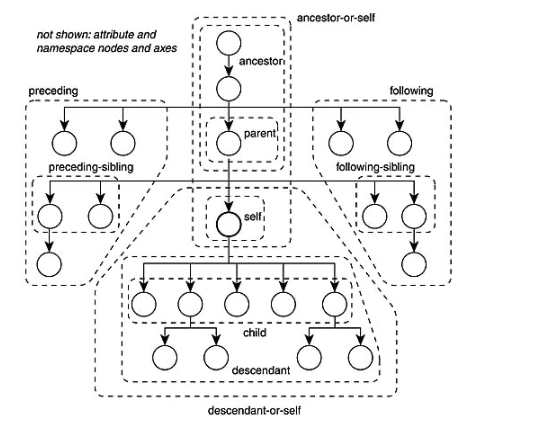

Diagram from [Sams Teach Yourself XSLT in 21 Days, Figure 3.5](https://www.informit.com/articles/article.aspx?p=29844&seqNum=3)


## 2B. All the Soup Methods

The following will show you all of the Beautiful Soup methods:

```python
soup_methods = [m for m in dir(BeautifulSoup) if m[0].islower()]
soup_methods
```

In [106]:
soup_methods = [m for m in dir(BeautifulSoup) if m[0].islower()]

# REMOVE THE FOLLOWING "#" to see all methods!
# soup_methods

## 3A. Exploring The MEI File as a Network Graph

Before digging into the details of the XML and starting to navigate these `soup` objects programmatically, let's visualize several XML snippets to get a high-level overview of how it is structured. 

First we will create several functions that we will use in the subsequent visualisations. Eventually you may choose to explore these functions and tweak their behavior, but for now we will use them as is:

In [107]:
def format_element(tag: bs4.element.Tag, wrap_length=20, exclude=[]):
    attrs_list = []
    for a, v in tag.attrs.items():
        if a in exclude:
            continue
        attrs_list.append(f"{a}={v}")
    formatted_string = f"{tag.name} ({' '.join(attrs_list)})" if attrs_list else tag.name
    return textwrap.fill(formatted_string, wrap_length)


def create_network(tag: bs4.element.Tag, with_attributes: bool = False, attrs_to_exclude=[]):
    all_tags = [tag] + tag.find_all()
    G = nx.DiGraph()
    for node in all_tags:
        depth = len(list(node.parents))
        G.add_node(
            id(node),
            label=format_element(node, exclude=attrs_to_exclude) if with_attributes else node.name,
            value=len(list(node.descendants)),
            group=depth,
            level=depth,
            scaling={'label': {'enabled': True}},
        )
    for node in all_tags:
        for child in node.children:
            if child.name:
                G.add_edge(id(node), id(child),
                           arrows='to',
                           id=f"{id(node)}_{node.name}|{id(child)}_{child.name}")
    return G

def display_network(network,
                    filename="tmp.html",
                    width=600,
                    height=600,
                    bgcolor="white",
                    font_color="black",
                    ):
    nt = Network(notebook=False, width=f"{width}px", height=f"{height}px", bgcolor=bgcolor, font_color=font_color)
    nt.from_nx(network)
    nt.save_graph(filename)

    with open(filename, 'r', encoding='utf-8') as f:
        html_content = f.read()

    # Replace all instances of the fixed pyvis id with a unique one
    unique_id = f"net_{uuid.uuid4().hex}"
    html_content = html_content.replace("mynetwork", unique_id)

    wrapped = f"""
    <div style="width:{width}px; height:{height}px; overflow:hidden;">
        {html_content}
    </div>
    """
    display(HTML(wrapped))

### Let's start with a network of the head elements

In [108]:
# get base filename of the mei file
basename = os.path.splitext(filename)[0]

# create the network from the meiHead element
head_nw = create_network(soup.find('meiHead'))

# display it, saving the html alongside the mei file
name = "head_network"
display_network(head_nw, filename=f"{name}_network.html")

In [109]:
### And now the music section

In [110]:
# get base filename of the mei file
basename = os.path.splitext(filename)[0]


# here we find the first 'music' element, which in turn shows all the measures


measure_network = create_network(soup.find('music'))

name = "measure_network.html"
display_network(measure_network, filename=f"{name}_network.html")

### 3B. Now with Attributes of those Elements

Already from this we can see that a `measure` element contains `staff` elements and so on.

Let's do the same thing again, but this time showing some **attributes**. We will hide the `xml:id` attributes since they are quite verbose:

In [111]:
# name for network
basename = os.path.splitext(filename)[0]

# selected measure
measure_to_display = 1

# show attributes of elements?
attributes = False

# THIS IS SLOW, SO PERHAPS ONLY REMOVE # IF YOU WANT TO SEE IT HERE!

# make the network
measure_network_with_attrs = create_network(
    soup.find("measure", {"n": measure_to_display}), 
    with_attributes=attributes, 
    attrs_to_exclude=["xml:id"]
)


name = "measure_network_with_attributes.html"
display_network(measure_network_with_attrs, filename=f"{name}_network.html")

### 3C. The Entire Piece as a Network

Last, let's create a **network of the entire piece**. We won't display it here because it risks slowing down our browser. Instead, we can save it to an HTML file and open that file separately:

In [112]:
our_piece_network = create_network(soup)

# don't run the following unless you want to take a coffee break . . . 
name = "complete_network.html"
display_network(our_piece_network, filename=f"{name}_network.html")

If you open that file in a browser you should see something like this!

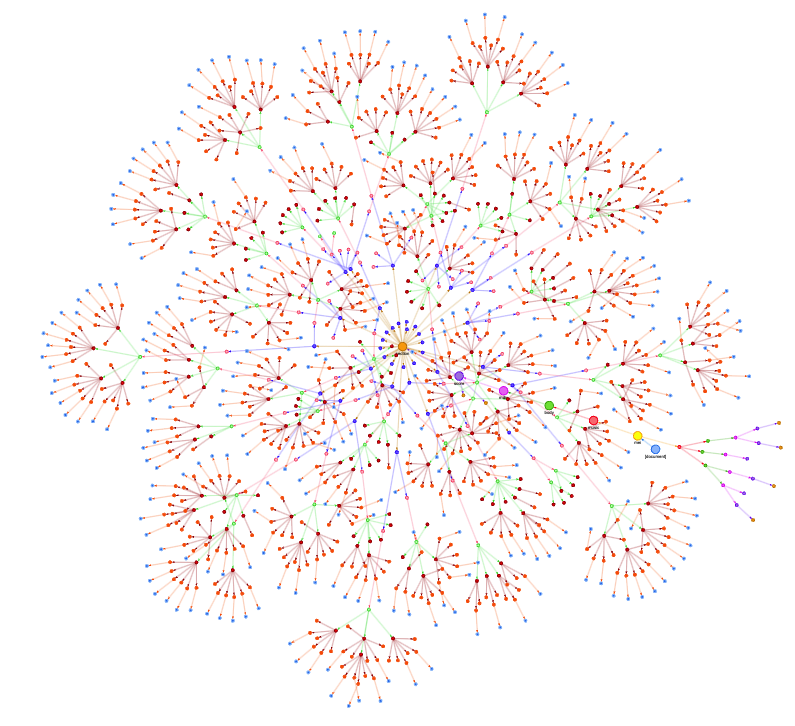

## 4. Metadata

More about the metadata. This code updates the following fields in the MEI:

- the **respStmt**, including names of composers and editors, with 'role' attributes, and with 'auth' and 'auth.uri' attributes for the composer
- the **titleStmt**, including the title of the musical work
- the **workList**, including the composer, work title, and genre (which is preserved under 'classification')
- the **manifestationList**, including the standard identifier (such as RISM) for the source, the title and date of the source, and up to two 'publishers' along with their 'auth' and 'auth.uri' attributes.  Also the city and institution where the source is to be found, and finally any shelf number of the source
- the **pubStmt**, where we record the overall location of this encoded file (such as The CRIM Project) along with the copyright owners, the rights statement, and the date on which this digital file was produced



#### 4a.  Work with Some Metadata Tags

Add or update some tags.  See the [Encoding Music Tutorial page](https://github.com/RichardFreedman/Encoding_Music/blob/main/01_Tutorials/12_Beautiful_Soup_MEI.md#return-the-text-of-a-tag) for ideas on how to return, edit, and add tags for composer, title, editors, analysts.

Try some of these methods out below!



In [113]:
# your turn here!

# the text of the composer element:
for tag in soup.find_all("persName", {"role": "composer"}):
    print(tag.text.strip())

Bach, Johann Sebastian


#### 4b.  Now work with the Full Metadata Sheet

We can also imagine working with an entire archive of our files, populating and updating names of pieces, editors, rights statements and other key metadata in a systematic way.

For this we will make use of:

- A Google sheet (where we will keep our metadta in human-readable form)
- A dataframe (importing a csv version of our sheet for use with Soup)
- Dictionaries (in effect json) created from each `row` of our dataframe, which in turn will be used to update our MEI
- An archive of the MEI files themselves

For reference here is [our metadata sheet](https://docs.google.com/spreadsheets/d/1jqzqeE-xNcD8Q0a3W-39W4l-oPkCDdWKpBlP3bQ7rUI/edit?usp=sharing)

In [143]:
# the model metadata is on Gdrive as a Google Sheet, which is in turn published as a CSV file. 
# here we load it as a Pandas dataframe


duo_metadata_url =  'https://docs.google.com/spreadsheets/d/e/2PACX-1vRqT44s-HWIBNcmBg1G_hmqT1R1pIXmldrITPK1xrnZjQckDmUccysGY4bUYaLbuelR9vVCmdpXBzhR/pub?output=csv'
duo_metadata_df = pd.read_csv(duo_metadata_url).fillna('')

# Convert the DataFrame to a dictionary

duo_metadata_dict = duo_metadata_df.to_dict(orient='records')

duo_metadata_df.head()

,Filename,Composer,VIAF,Date,Title,Catalog,XML_Editor,MEI_Editor_1,Analyst,Source,Rights,Last_Updated
0,Bach_BWV_0772.mei,"Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,1723,Invention No. 1 in C major,BWV 772,"Schölkopf, Tobias","Freedman, Richard",Grace Quasebarth,https://tobis-notenarchiv.de/wp/en/bach-archiv...,The content and works published on this websit...,
1,Bach_BWV_0773.mei,"Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,1723,Invention No. 2 in C minor,BWV 773,"Schölkopf, Tobias","Freedman, Richard",Jacob Jahiel,https://tobis-notenarchiv.de/wp/en/bach-archiv...,The content and works published on this websit...,
2,Bach_BWV_0774.mei,"Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,1723,Invention No. 3 in D major,BWV 774,"Schölkopf, Tobias","Freedman, Richard",Patricia Tang,https://tobis-notenarchiv.de/wp/en/bach-archiv...,The content and works published on this websit...,
3,Bach_BWV_0775.mei,"Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,1723,Invention No. 4 in D minor,BWV 775,"Schölkopf, Tobias","Freedman, Richard",Zara Fox,https://tobis-notenarchiv.de/wp/en/bach-archiv...,The content and works published on this websit...,
4,Bach_BWV_0776.mei,"Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,1723,Invention No. 5 in E-flat major,BWV 776,"Schölkopf, Tobias","Freedman, Richard",Ella Manning,https://tobis-notenarchiv.de/wp/en/bach-archiv...,The content and works published on this websit...,


### 4B. Sample Dictionary Entries

In [144]:
# here is ONE sample 'dictionary' version of the file.  It represents a single row from the sheet and dataframe
duo_metadata_dict[0:1] # use Python list slicing to find other rows, or a range of them

[{'Filename': 'Bach_BWV_0772.mei',
  'Composer': 'Bach, Johann Sebastian',
  'VIAF': 'https://viaf.org/viaf/12304462/',
  'Date': 1723,
  'Title': 'Invention No. 1 in C major',
  'Catalog': 'BWV 772',
  'XML_Editor': 'Schölkopf, Tobias',
  'MEI_Editor_1': 'Freedman, Richard',
  'Analyst': 'Grace Quasebarth',
  'Source': 'https://tobis-notenarchiv.de/wp/en/bach-archive/instrumental-works/keyboard-works/inventions/',
  'Rights': 'The content and works published on this website are governed by the copyright laws of Germany. Any duplication, processing, distribution or any form of utilisation beyond the scope of copyright law shall require the prior written consent of the author or authors in question.',
  'Last_Updated': ''}]

### 4C. Functions for Loading, Updating and Saving MEI

In [145]:
# opens file with soup and returns soup object
def open_file(filename):
    with open(filename, 'rb') as file:
        # print(filename)
        # Detect the encoding
        result = chardet.detect(file.read())
        # Seek to the beginning of the file
        file.seek(0)
        # Decode the file using the detected encoding
        content = file.read().decode(result['encoding'])
        file_name = os.path.basename(filename)
        # print(file_name)
        base_name, extension = os.path.splitext(file_name) 
        file_name_for_dict_check = base_name + extension
        revised_name = base_name + "_rev" + extension
        soup = BeautifulSoup(content, 'xml')
        
        return soup, file_name_for_dict_check, revised_name
    
# saves the file as XML
def save_xml(soup_object, new_filename):
    folder_path = "Updates/"
    file_path = os.path.join(folder_path, new_filename)
    pretty_xml = soup.prettify()
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(str(pretty_xml))
        

### 4D.  Get the Files and Update the Metadata with our new Analysts

Here we will work with each file in turn.  First we get the file, then the matching dictionary of metadata.  Finally, we update the Analyst tag to match the dictionary contents!

In [146]:
file_list = glob.glob('MEI/*')
# file_list

### 

In [148]:
def update_analyst(soup, matching_dict):
    respStmt = soup.find('fileDesc').find('respStmt')
    analyst_tag = respStmt.find('persName', role='analyst')
    if analyst_tag:
        analyst_tag.string = matching_dict.get('Analyst', '')
        print(f"Updated analyst to: {analyst_tag.string}")
    else:
        print(f"Warning: no analyst tag found")
    return soup

# make sure we have the Folder for the new files!
os.makedirs("Updates", exist_ok=True)

for file_name in file_list:
    soup_with_names = open_file(file_name)
    soup = soup_with_names[0]
    old_filename = soup_with_names[1]
    new_filename = soup_with_names[2]

    matching_dict = next((item for item in duo_metadata_dict if item['Filename'] == old_filename), None)
    print("Processing " + old_filename)

    soup = update_analyst(soup, matching_dict)
    save_xml(soup, new_filename)

Processing Morley_1595_12_Flora_wilt_thou.mei
Updated analyst to: Zara Fox
Processing Bartok_Mikrokosmos_035.mei
Updated analyst to: Grace Quasebarth
Processing Bartok_Mikrokosmos_025.mei
Updated analyst to: Grace Quasebarth
Processing Bartok_Mikrokosmos_058.mei
Updated analyst to: Ella Manning
Processing Bartok_Mikrokosmos_029.mei
Updated analyst to: Zara Fox
Processing Bach_BWV_0780.mei
Updated analyst to: Patricia Tang
Processing Bach_BWV_0778.mei
Updated analyst to: Grace Quasebarth
Processing Bartok_Mikrokosmos_028.mei
Updated analyst to: Patricia Tang
Processing Bartok_Mikrokosmos_026.mei
Updated analyst to: Jacob Jahiel
Processing Bach_BWV_0785.mei
Updated analyst to: Jacob Jahiel
Processing Bach_BWV_0774.mei
Updated analyst to: Patricia Tang
Processing Bartok_Mikrokosmos_031.mei
Updated analyst to: Elizabeth Garazzo
Processing Bach_BWV_0773.mei
Updated analyst to: Jacob Jahiel
Processing Morley_1595_10_O_thou_that_art.mei
Updated analyst to: Jacob Jahiel
Processing Bach_BWV_078

### 4F. Checking Composer Title Update

Now back to the Updated Files:  

- list the files
- find the names of those associated with the piece and file


In [91]:
updated_file_list = glob.glob('Updates/*')


updated_file_list

['Updates/Bach_BWV_0772_rev.mei',
 'Updates/Bach_BWV_0782_rev.mei',
 'Updates/Bach_BWV_0773_rev.mei',
 'Updates/Bach_BWV_0781_rev.mei',
 'Updates/Bach_BWV_0784_rev.mei',
 'Updates/Morley_1595_03_Sweet_nymph_rev.mei',
 'Updates/Bach_BWV_0777_rev.mei',
 'Updates/Bach_BWV_0780_rev.mei',
 'Updates/Bartok_Mikrokosmos_031_rev.mei',
 'Updates/Bach_BWV_0786_rev.mei',
 'Updates/Morley_1595_10_O_thou_that_art_rev.mei',
 'Updates/Bartok_Mikrokosmos_030_rev.mei',
 'Updates/Bach_BWV_0774_rev.mei',
 'Updates/Bartok_Mikrokosmos_035_rev.mei',
 'Updates/Bartok_Mikrokosmos_024_rev.mei',
 'Updates/Bartok_Mikrokosmos_092_rev.mei',
 'Updates/Morley_1595_12_Flora_wilt_thou_rev.mei',
 'Updates/Morley_1595_11_I_should_for_griefe_rev.mei',
 'Updates/Bach_BWV_0775_rev.mei',
 'Updates/Bartok_Mikrokosmos_037_rev.mei',
 'Updates/Bartok_Mikrokosmos_022_rev.mei',
 'Updates/Bartok_Mikrokosmos_023_rev.mei',
 'Updates/Morley_1595_06_Lo_hear_another_rev.mei',
 'Updates/Bach_BWV_0776_rev.mei',
 'Updates/Bartok_Mikrokosmo

In [149]:
# now we rebuild a table based on the metadata from the updated files!

# list of dictionaries, which we will combine later
list_dicts = []

for filename in updated_file_list:  
    with open(filename, encoding="utf-8") as file:
        print("Processing " + filename)
        # Seek to the beginning of the file
        file.seek(0)
        file_name = os.path.basename(filename)
        soup = BeautifulSoup(file, 'xml')
        
        
        # find all the people
        persons = soup.find('fileDesc').find('respStmt').find_all('persName')
        
        # find the title
        soupTitle = soup.find('fileDesc').find('titleStmt').find('title')
        title = soupTitle.string.strip()
        
        # with each person, determine name, and other details, according to role
        for person in persons:
            if person['role'] == 'composer':
                compName = person.string.strip()
                viaf = person.attrs["auth.uri"]
            if person['role'] == 'xml_editor':
                xmlEdName = person.string.strip()
            if person['role'] == 'mei_editor':
                meiEdName = person.string.strip()
            if person['role'] == 'analyst':
                analyistName = person.string.strip()
                
        # create and populate a temporary dictionary
        temp_dict = {}
        temp_dict['file'] = file_name
        temp_dict['title'] = title
        temp_dict['composer'] = compName
        temp_dict['viaf'] = viaf
        temp_dict['xml_editor'] = xmlEdName
        temp_dict['mei_editor'] = meiEdName
        temp_dict['analyst'] = analyistName
        
        # add each dictionary to the list of dictionaries
        list_dicts.append(temp_dict)
        
# with the list of dictionaries, create a dataframe
output = pd.DataFrame(list_dicts)
output
        

Processing Updates/Bach_BWV_0772_rev.mei
Processing Updates/Bach_BWV_0782_rev.mei
Processing Updates/Bach_BWV_0773_rev.mei
Processing Updates/Bach_BWV_0781_rev.mei
Processing Updates/Bach_BWV_0784_rev.mei
Processing Updates/Morley_1595_03_Sweet_nymph_rev.mei
Processing Updates/Bach_BWV_0777_rev.mei
Processing Updates/Bach_BWV_0780_rev.mei
Processing Updates/Bartok_Mikrokosmos_031_rev.mei
Processing Updates/Bach_BWV_0786_rev.mei
Processing Updates/Morley_1595_10_O_thou_that_art_rev.mei
Processing Updates/Bartok_Mikrokosmos_030_rev.mei
Processing Updates/Bach_BWV_0774_rev.mei
Processing Updates/Bartok_Mikrokosmos_035_rev.mei
Processing Updates/Bartok_Mikrokosmos_024_rev.mei
Processing Updates/Bartok_Mikrokosmos_092_rev.mei
Processing Updates/Morley_1595_12_Flora_wilt_thou_rev.mei
Processing Updates/Morley_1595_11_I_should_for_griefe_rev.mei
Processing Updates/Bach_BWV_0775_rev.mei
Processing Updates/Bartok_Mikrokosmos_037_rev.mei
Processing Updates/Bartok_Mikrokosmos_022_rev.mei
Processi

,file,title,composer,viaf,xml_editor,mei_editor,analyst
0,Bach_BWV_0772_rev.mei,"Invention No. 1 in C major, BWV 772","Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,"SchÃ¶lkopf, Tobias","Freedman, Richard",Grace Quasebarth
1,Bach_BWV_0782_rev.mei,"Invention No. 11 in G minor, BWV 782","Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,"SchÃ¶lkopf, Tobias","Freedman, Richard",Ella Manning
2,Bach_BWV_0773_rev.mei,"Invention No. 2 in C minor, BWV 773","Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,"SchÃ¶lkopf, Tobias","Freedman, Richard",Jacob Jahiel
3,Bach_BWV_0781_rev.mei,"Invention No. 10 in G major, BWV 781","Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,"SchÃ¶lkopf, Tobias","Freedman, Richard",Zara Fox
4,Bach_BWV_0784_rev.mei,"Invention No. 13 in A minor, BWV 784","Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,"SchÃ¶lkopf, Tobias","Freedman, Richard",Grace Quasebarth
5,Morley_1595_03_Sweet_nymph_rev.mei,"Sweet nymph, RISM A/I: M 3701. No. 3","Morley, Thomas",https://viaf.org/viaf/77117535,André Vierendeels,Richard Freedman,Grace Quasebarth
6,Bach_BWV_0777_rev.mei,"Invention No. 6 in E major, BWV 777","Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,"SchÃ¶lkopf, Tobias","Freedman, Richard",Elizabeth Garazzo
7,Bach_BWV_0780_rev.mei,"Invention No. 9 in F minor, BWV 780","Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,"SchÃ¶lkopf, Tobias","Freedman, Richard",Patricia Tang
8,Bartok_Mikrokosmos_031_rev.mei,Mikrokosmos No. 31: Little Dance in Canon Form...,"Bartók, Béla",https://viaf.org/viaf/89006617/,"Ramoneda, Pedro","Freedman, Richard",Elizabeth Garazzo
9,Bach_BWV_0786_rev.mei,"Invention No. 15 in B minor, BWV 786","Bach, Johann Sebastian",https://viaf.org/viaf/12304462/,"SchÃ¶lkopf, Tobias","Freedman, Richard",Patricia Tang


# 5.    Your Turn with Soup and MEI

Here you will experiment with various methods as you learn to "climb" the XML tree to report various data and metadata.


#### What is your Motivation?  What do you want to learn about your pieces?


Add your motivation here . . . 



## 5A.  A Closer Look:  One Measure as XML

XML files are very long, so let's just look at one bar;

`print(soup.find("measure", {"n": 1}).prettify())`


In [150]:
# load one of your files
path = 'MEI/Bach_BWV_0785.mei'

# remember, our open_file returns a tuple; so let's get just the first item|
soup = open_file(path)[0]

In [151]:
# find measure according to it's 'n' attribute
print(soup.find("measure", {"n": 1}).prettify())

<measure n="1" xml:id="m-40">
 <staff n="1" xml:id="m-42">
  <layer n="1" xml:id="m-43">
   <rest dur="16" dur.ppq="64" tstamp.real="00:00:00" xml:id="m-44"/>
   <beam xml:id="m-47">
    <note dur="32" dur.ppq="32" oct="4" pname="b" pnum="70" stem.dir="down" tstamp.real="00:00:00.25" vel="0" xml:id="m-45">
     <accid accid.ges="f" xml:id="m-46"/>
    </note>
    <note breaksec="1" dur="32" dur.ppq="32" oct="5" pname="c" pnum="72" stem.dir="down" tstamp.real="00:00:00.375" vel="0" xml:id="m-48"/>
    <note dur="32" dur.ppq="32" oct="5" pname="d" pnum="74" stem.dir="down" tstamp.real="00:00:00.5" vel="0" xml:id="m-49"/>
    <note dur="32" dur.ppq="32" oct="5" pname="c" pnum="72" stem.dir="down" tstamp.real="00:00:00.625" vel="0" xml:id="m-50"/>
    <note dur="16" dur.ppq="64" oct="4" pname="b" pnum="70" stem.dir="down" tstamp.real="00:00:00.75" vel="0" xml:id="m-51">
     <accid accid.ges="f" xml:id="m-52"/>
    </note>
   </beam>
   <beam xml:id="m-54">
    <note dur="16" dur.ppq="64" 

## 5B.  Staves, Clefs, Notes



In [152]:
# All the Staves as a List
staves = soup.find_all("staffDef")
# interate through them:
for staff in staves:
    print(staff.prettify())

<staffDef clef.line="2" clef.shape="G" key.mode="major" key.sig="2f" lines="5" n="1" xml:id="m-28">
 <label xml:id="m-29">
  Piano
 </label>
 <labelAbbr xml:id="m-30">
  Pno.
 </labelAbbr>
 <!-- keyboard.piano.grand -->
 <instrDef midi.channel="1" midi.pan="53" midi.volume="100" xml:id="m-32"/>
</staffDef>

<staffDef clef.line="4" clef.shape="F" key.mode="major" key.sig="2f" lines="5" n="2" xml:id="m-33">
 <label xml:id="m-34">
  Piano
 </label>
 <labelAbbr xml:id="m-35">
  Pno.
 </labelAbbr>
 <!-- keyboard.piano.grand -->
 <instrDef midi.channel="1" midi.pan="53" midi.volume="100" xml:id="m-37"/>
</staffDef>



In [153]:
# Find just the First Staff 
print(soup.find_all("staffDef")[0].prettify())

<staffDef clef.line="2" clef.shape="G" key.mode="major" key.sig="2f" lines="5" n="1" xml:id="m-28">
 <label xml:id="m-29">
  Piano
 </label>
 <labelAbbr xml:id="m-30">
  Pno.
 </labelAbbr>
 <!-- keyboard.piano.grand -->
 <instrDef midi.channel="1" midi.pan="53" midi.volume="100" xml:id="m-32"/>
</staffDef>



In [154]:
# Staves with a certain clef shape
for g_clef in soup.find_all("staffDef", {'clef.shape' : 'G'}):
    print(g_clef.prettify())

<staffDef clef.line="2" clef.shape="G" key.mode="major" key.sig="2f" lines="5" n="1" xml:id="m-28">
 <label xml:id="m-29">
  Piano
 </label>
 <labelAbbr xml:id="m-30">
  Pno.
 </labelAbbr>
 <!-- keyboard.piano.grand -->
 <instrDef midi.channel="1" midi.pan="53" midi.volume="100" xml:id="m-32"/>
</staffDef>



### 5C. Your Turn==> Take the Measure Challenge!

How would you . . .

- Find **all the measures** (warning, this could be LONG!:

- Find the **last measure** and print it:

- Find the **first staff of the last measure**:

- Find a particular measure by its number attribute:

Need help?  [Try Encoding MusicTutorial](https://github.com/RichardFreedman/Encoding_Music/blob/main/01_Tutorials/12_Beautiful_Soup_MEI.md#find-and-count-measures)

In [155]:
# your work here


### 5D. Your Turn==> How about Finding Notes?


How would you . . .

- **All the notes**

- The **last note** 

- the **LAST note of the FIRST staff**

- The **pitch** of that note (which is one of its attributes)


Need help?  [Try Encoding MusicTutorial](https://github.com/RichardFreedman/Encoding_Music/blob/main/01_Tutorials/12_Beautiful_Soup_MEI.md#find-and-count-measures)


In [156]:
# your work here



### 5E. Your Turn==> Sharps and Flats 

MEI handles sharps and flats in some subtle ways!  

The `keySig` is specified as child of the `scoreDef` tag.  In this case the attribute `sig` shows we have three flats (`3f`).  It does not tell us _which_ notes are flats!

```xml
<scoreDef xml:id="s11mdyqc">
      <staffGrp xml:id="s129tyk2">
       <staffGrp bar.thru="true" xml:id="P1">
        <grpSym symbol="brace" xml:id="g8v8p98"/>
        <instrDef midi.channel="0" midi.instrnum="1" xml:id="i1sxlwxv"/>
        <staffDef lines="5" n="1" ppq="480" xml:id="s1vfmex8">
         <clef line="2" shape="G" xml:id="cuklt79"/>
         <keySig mode="major" sig="3f" xml:id="kp8lj9z"/>
         <meterSig count="4" unit="4" xml:id="ma1fduw"/>
        </staffDef>
        <staffDef lines="5" n="2" ppq="480" xml:id="s1mvbsoi">
         <clef line="4" shape="F" xml:id="cuklt81"/>
         <keySig mode="major" sig="3f" xml:id="klruzwp"/>
         <meterSig count="4" unit="4" xml:id="m91k274"/>
        </staffDef>
       </staffGrp>
      </staffGrp>
     </scoreDef>
```

Now, when we find some note that is to be 'inflected' as one of those flats (or sharps) these notes are given a special attribute:  `accid.ges` (short for 'accidental gesture').  Here is a measure with one such 'inflected note':

```xml
<note accid.ges="f" dur="16" dur.ppq="120" oct="5" pname="e" xml:id="n45t30a"/>
```

Notes not covered by these 'gestural' accidentals (the ones specified by the key signature) are instead marked with local accidentals.  These are encoded as `accid` elements of their own, and as a `child` element of the note they modify:

```xml
<note dur="16" dur.ppq="120" oct="4" pname="b" xml:id="njxj0i">
           <accid accid="n" xml:id="a1ctcoax"/>
          </note>
```


In [157]:
# your work here

### 5F. Basic Note Counting (and Some Charts and Graphs)

Now let's assemble the various results into a `list` of pitches, and then use Pandas and Counter to help us compare pieces, make visualizations, and so on.


In [158]:
accid_map = {"s": "#", "f": "b", "ss": "##", "ff": "bb", "n": "♮", "": ""}

pitches = []
notes = soup.find_all('note')
for note in notes:
    pname = note.get('pname')
    if pname is None:
        continue
    accid_tag = note.find("accid")
    if accid_tag is not None:
        accid = accid_tag.get("accid.ges") or accid_tag.get("accid") or ""
    else:
        accid = ""
    pitch_class = f"{pname}{accid_map.get(accid, accid)}" if accid else pname
    pitches.append(pitch_class)

# total note count
total_n = len(pitches)

# build dataframe with scaled counts
counted = Counter(pitches)
counted_notes = pd.Series(counted).to_frame('count').sort_index().reset_index()
counted_notes['scaled'] = counted_notes['count'] / total_n
counted_notes.rename(columns={"index": "Pitch_Class", "count": "Count", "scaled": "Scaled_Count"}, inplace=True)
counted_notes

,Pitch_Class,Count,Scaled_Count
0,a,47,0.079125
1,ab,20,0.033670
2,a♮,8,0.013468
3,b,1,0.001684
4,bb,90,0.151515
5,b♮,2,0.003367
6,c,92,0.154882
7,d,84,0.141414
8,e,3,0.005051
9,eb,79,0.132997


### 5G. A Chart of Pitch Classes

You can adapt this as needed . . 

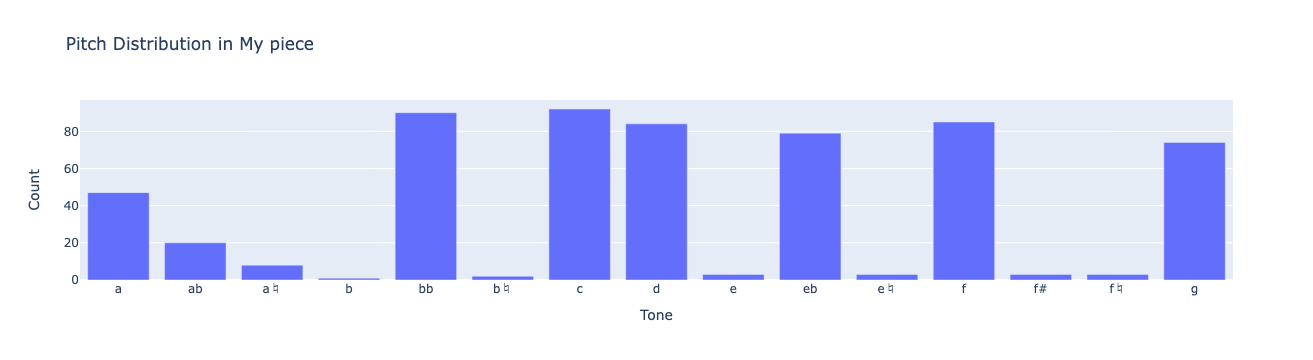

In [159]:
fig = px.bar(counted_notes, 
             x='Pitch_Class', 
             y="Count", 
             title="Pitch Distribution in My piece")
fig.update_xaxes(title_text="Tone")
fig.update_yaxes(title_text="Count")
fig.show()

### 5H. A Radar Plot of Those Pitches

```python
categories = list(counted_notes['Pitch_Class'])
angles = [n / len(categories) * 2 * math.pi for n in range(len(categories))]
angles += angles[:1]

# Create the polar plot
fig = px.line_polar(counted_notes, 
                    r=counted_notes["Scaled_Count"], 
                    theta=categories, 
                    line_close=True)
# Create title for the chart
fig.update_layout(title_text="Relative Distribution of Notes in " + soup.find('title').text.strip())
fig.show()
```

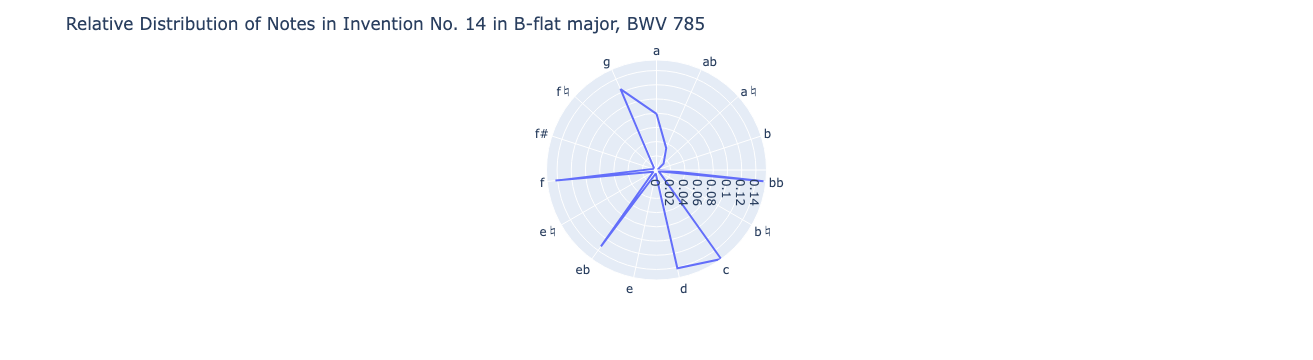

In [160]:
categories = list(counted_notes['Pitch_Class'])
angles = [n / len(categories) * 2 * math.pi for n in range(len(categories))]
angles += angles[:1]

# Create the polar plot
fig = px.line_polar(counted_notes, 
                    r=counted_notes["Scaled_Count"], 
                    theta=categories, 
                    line_close=True)
# Create title for the chart
fig.update_layout(title_text="Relative Distribution of Notes in " + soup.find('title').text.strip())
fig.show()

### 5I. Barchart of Notes in Each Staff



In [140]:
def get_pitch_dist(n, soup):
    accid_map = {"s": "#", "f": "b", "ss": "##", "ff": "bb", "n": "♮", "": ""}
    staves = soup.find_all("staff", n=n)
    staff_notes = []
    for staff in staves:
        notes = staff.find_all("note")
        for note in notes:
            pname = note.get("pname")
            if pname is None:
                continue
            accid_tag = note.find("accid")
            if accid_tag is not None:
                accid = accid_tag.get("accid.ges") or accid_tag.get("accid") or ""
            else:
                accid = ""
            pitch_class = f"{pname}{accid_map.get(accid, accid)}" if accid else pname
            staff_notes.append(pitch_class)
    note_counts = pd.Series(Counter(staff_notes)).to_frame(n).sort_index()
    return note_counts


# infer staff count from scoreDef
num_staves = len(soup.find_all('staffDef'))
df = get_pitch_dist(1, soup)
for i in range(2, num_staves + 1):
    df = pd.concat([df, get_pitch_dist(i, soup)], axis=1)

df = df.reset_index().rename(columns={'index': 'Note'})
df_melt = pd.melt(df, id_vars='Note', value_vars=list(range(1, num_staves + 1))).rename(
    columns={'variable': 'Voice', 'value': 'Count'}
)
df_melt

,Note,Voice,Count
0,a,1,15.0
1,ab,1,14.0
2,a♮,1,6.0
3,bb,1,38.0
4,b♮,1,1.0
5,c,1,43.0
6,d,1,43.0
7,eb,1,48.0
8,e♮,1,1.0
9,f,1,47.0


### 5G. A Chart of Pitches in the Two Staves

```python
# A bar chart of the notes per staff:
fig = px.bar(df_melt, 
             x='Note', 
             y='Voice', 
title="Pitch Distribution in " + soup.title.text.strip() + " by Staff")
fig.update_xaxes(title_text="Note")
fig.update_yaxes(title_text="Count")
fig.show()
```

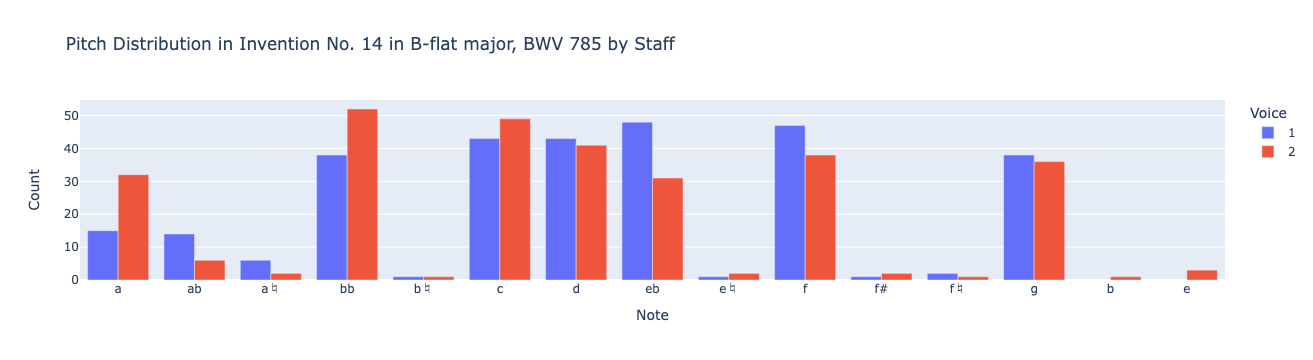

In [141]:
# A bar chart of the notes per staff:
fig = px.bar(df_melt, 
             x='Note', 
             y='Count',
             color='Voice',
             barmode='group',
            title="Pitch Distribution in " + soup.title.text.strip() + " by Staff")
fig.update_xaxes(title_text="Note")
fig.update_yaxes(title_text="Count")
fig.show()

### 7.  New Ideas of Your Own?

- Counting durations?
- working with `pnum` (which are midi values)
- looking for events according to certain measures (all the tones in measure 1 vs last measure)
- comparing two or more pieces?  Which has the widest range?  Count of measures?

In [ ]:
# your work here

### 8.  Taking Stock of What You Learned

- What did you learn about MEI and XML?  